In [1]:
### sample_data - ATOC5860 Lecture #9
### coded by Libby Barnes (CSU), additional commenting/updating by Jennifer Kay (CU)
### Last updated February 24, 2022
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import scipy.signal as sig
import scipy.stats as stats
from matplotlib.gridspec import GridSpec
## needed in ipython notebooks to make plots appear in-line

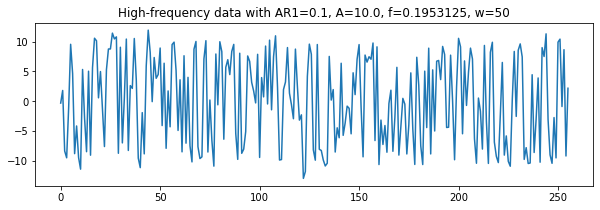

In [30]:
### Construct a synthetic timeseries with power at at a given frequency, specified memory, and specified noise.

#%% input parameters
T = 256                 #length of record (default 256)
alpha = 0.1             #red noise lag-one autocorrelation (default 0.5, try increasing to 0.9 or decreasing to 0.1)
xcosamp = 10.0          #amplitude of oscillation (default 0.5, try increasing to 5 or decreasing to 0.1)
xcosfreq = (50./256.)   #frequency of oscillation (default 50./256., try 10./256. or 100./256.)
noiselevel= 0.1        #noise level (default 0.01)
w=round(xcosfreq*T)            #wave number, # of oscillations that fit in the domain

# Example realization - red noise with oscillation
fig=plt.figure(figsize=(10,3))
factor = np.sqrt(1.-alpha*alpha)
x = np.zeros(T,)
x[0] = x[-1]*alpha + factor*np.random.randn() 
for j in np.arange(1,T,1):
    x[j] = x[j-1]*alpha + factor*np.random.randn()+xcosamp*np.cos(2.*np.pi*(1.-noiselevel*np.random.randn())*xcosfreq*j)
plt.plot(x);
plt.title('High-frequency data with AR1='+str(alpha)+', A='+str(xcosamp)+', f='+str(xcosfreq)+', w='+str(w));

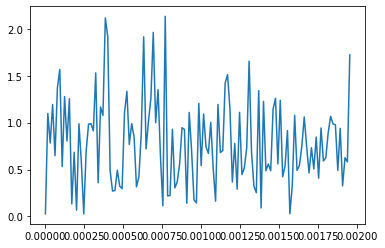

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack

N = len(x)
yf = scipy.fftpack.fft(x)
xf = np.linspace(0.0, 1.0/(2.0*T), N//2)

fig, ax = plt.subplots()
ax.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.show()

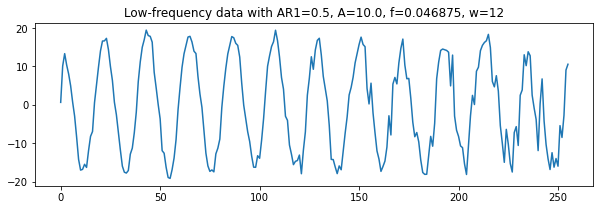

In [17]:
### Construct another synthetic timeseries... vary the frequency, memory, and noise
### e.g. below, lower frequency, but same noise and memory

#%% input parameters
T = 256                 #length of record (default 256)
alpha = 0.5               #red noise lag-one autocorrelation (default 0.5, try increasing to 0.9 or decreasing to 0.1)
xcosamp = 10.0          #amplitude of oscillation (default 0.5, try increasing to 5 or decreasing to 0.1)
xcosfreq = (12./256.)   #frequency of oscillation (default 50./256., try 10./256. or 100./256.)
noiselevel= 0.01       #noise level (default 0.01)
w=round(xcosfreq*T)     #wave number, # of oscillations that fit in the domain

# Example realization - red noise with oscillation
fig=plt.figure(figsize=(10,3))
factor = np.sqrt(1.-alpha*alpha)
x = np.zeros(T,)
x[0] = x[-1]*alpha + factor*np.random.randn() 
for j in np.arange(1,T,1):
    x[j] = x[j-1]*alpha + factor*np.random.randn()+xcosamp*np.cos(2.*np.pi*(1.-noiselevel*np.random.randn())*xcosfreq*j)
plt.plot(x);
plt.title('Low-frequency data with AR1='+str(alpha)+', A='+str(xcosamp)+', f='+str(xcosfreq)+', w='+str(w));